<a href="https://colab.research.google.com/github/KarthikSaravanakumarM56/24ADI003-24BAD056/blob/main/ML_Exp_10_scenario1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

24BAD056 - M.Karthik Saravanakumar
SVD RMSE: 0.7729268967084666
SVD MAE: 0.5578974831914701

Top Recommendations for User 1:
      movieId                                              title
31         32          Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
277       318                   Shawshank Redemption, The (1994)
474       541                                Blade Runner (1982)
659       858                              Godfather, The (1972)
4800     7153  Lord of the Rings: The Return of the King, The...


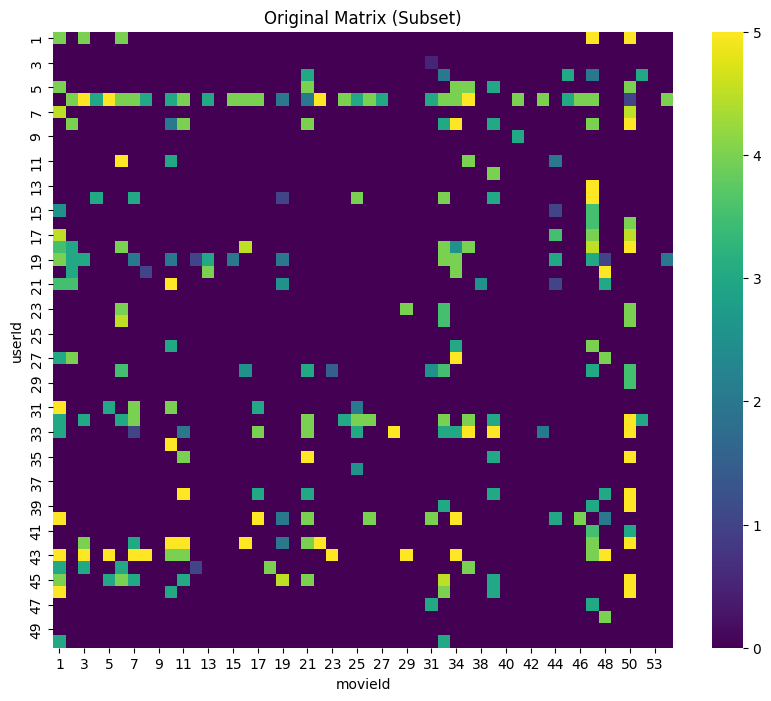

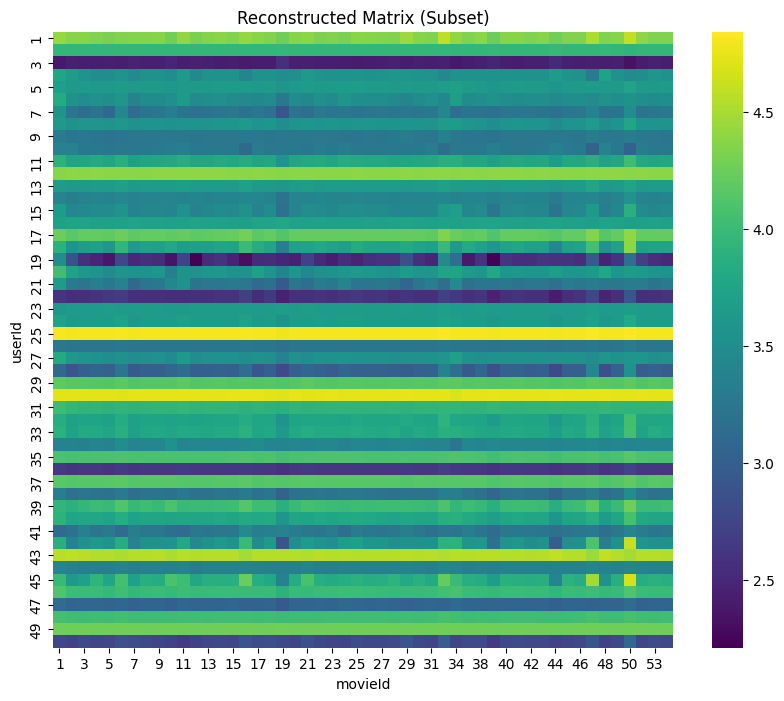

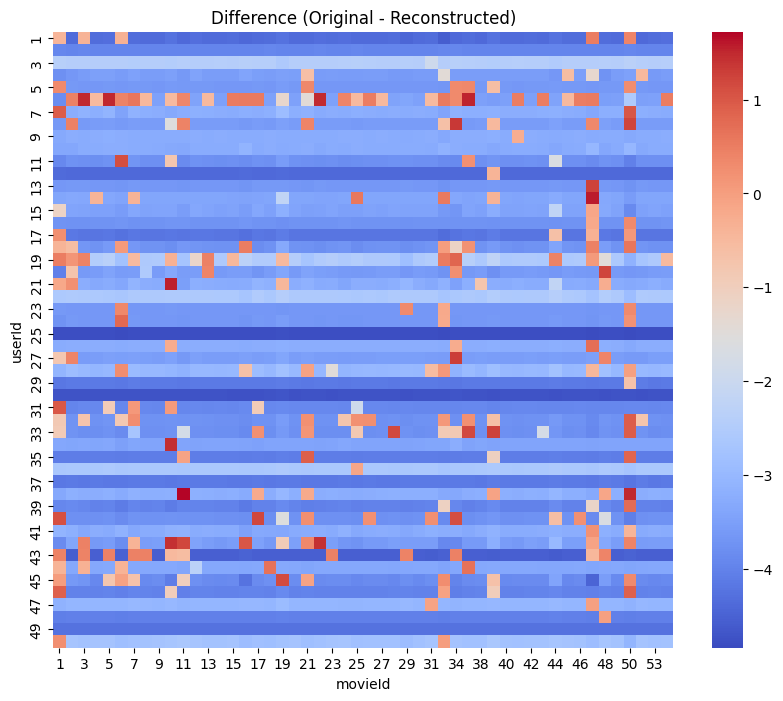

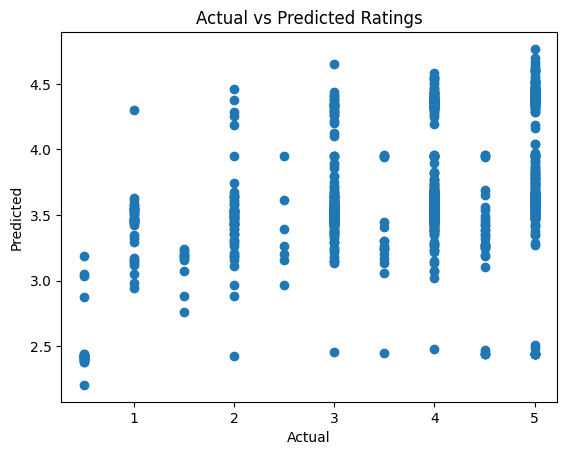

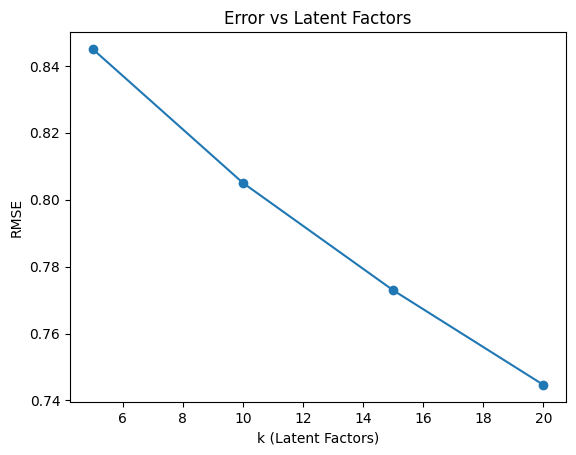

In [1]:
print("24BAD056 - M.Karthik Saravanakumar")

# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 2. LOAD DATASET
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

if 'timestamp' in ratings.columns:
    ratings = ratings.drop('timestamp', axis=1)

# 3. USER-ITEM MATRIX
user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')

# 4. NORMALIZATION (IMPORTANT FIX)
# Use mean only on available ratings (NOT filled zeros)
user_mean = user_item_matrix.mean(axis=1)

# Subtract mean and fill missing with 0 AFTER normalization
matrix_norm = user_item_matrix.sub(user_mean, axis=0).fillna(0)

# 5. APPLY SVD
U, sigma, Vt = np.linalg.svd(matrix_norm, full_matrices=False)

k = 15   # Reduced k for better generalization

U_k = U[:, :k]
sigma_k = np.diag(sigma[:k])
Vt_k = Vt[:k, :]

# 6. RECONSTRUCTION
reconstructed = np.dot(np.dot(U_k, sigma_k), Vt_k)

# Add mean back
reconstructed += user_mean.values.reshape(-1, 1)

pred_svd = pd.DataFrame(reconstructed,
                        index=user_item_matrix.index,
                        columns=user_item_matrix.columns)

# 7. EVALUATION (CORRECT)
mask = user_item_matrix.notna()

actual = user_item_matrix.values[mask]
predicted = pred_svd.values[mask]

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("SVD RMSE:", rmse)
print("SVD MAE:", mae)

# 8. RECOMMENDATIONS
def recommend_svd(user_id, n=5):
    user_row = pred_svd.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index
    recs = user_row.drop(already_rated).sort_values(ascending=False).head(n)
    return movies[movies['movieId'].isin(recs.index)][['movieId', 'title']]

print("\nTop Recommendations for User 1:")
print(recommend_svd(1))

# 9. VISUALIZATION
subset_original = user_item_matrix.fillna(0).iloc[:50, :50]
subset_reconstructed = pred_svd.iloc[:50, :50]

plt.figure(figsize=(10, 8))
sns.heatmap(subset_original, cmap='viridis')
plt.title("Original Matrix (Subset)")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(subset_reconstructed, cmap='viridis')
plt.title("Reconstructed Matrix (Subset)")
plt.show()

difference = subset_original - subset_reconstructed

plt.figure(figsize=(10, 8))
sns.heatmap(difference, cmap='coolwarm')
plt.title("Difference (Original - Reconstructed)")
plt.show()

# 10. ACTUAL vs PREDICTED
plt.figure()
plt.scatter(actual[:1000], predicted[:1000])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Ratings")
plt.show()

# 11. ERROR vs k
k_values = [5, 10, 15, 20]
errors = []

for k in k_values:
    U_k = U[:, :k]
    sigma_k = np.diag(sigma[:k])
    Vt_k = Vt[:k, :]

    recon = np.dot(np.dot(U_k, sigma_k), Vt_k)
    recon += user_mean.values.reshape(-1, 1)

    pred = recon[mask]
    err = np.sqrt(mean_squared_error(actual, pred))
    errors.append(err)

plt.figure()
plt.plot(k_values, errors, marker='o')
plt.xlabel("k (Latent Factors)")
plt.ylabel("RMSE")
plt.title("Error vs Latent Factors")
plt.show()